In [1]:
# Cell 1: imports and display options

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)


In [2]:
import os
os.chdir('/Users/zolf/Desktop/T1')

In [5]:
# Cell 2: load raw dataset (change filename if needed)

df = pd.read_csv("DatabasePietro.xlsx - genotipi28nov.csv", decimal=",")  # <--  real filename here

print("Shape:", df.shape)
df.head()


Shape: (165, 44)


,ID,MAOAuVNTR,Eta,QI,adhd,farmaco,cse,emotional,neglect,physical,AD,RBB,AB,TOTINT,TOTEXT,APQ_POS,APQ_NEG,APSD_CU,APSD_IMP,APSD_NARCI,Sintomi_DOP,ER_paura,ER_tristezza,ER_rabbia,ER_felicità,ER_disgusto,FC_E_AN,FC_E_HA,FC_E_SA,FC_E_FE,FC_E_DI,FFD_E_AN,FFD_E_HA,FFD_E_SA,FFD_E_FE,FFD_E_DI,FD_E_AN,FD_E_HA,FD_E_SA,FD_E_FE,FD_E_DI,APSD_CU1,AQ_Predatoria1,ICU_Total1
0,1,"4,0",7,122,1,2,3,1,1,1,55,63,65,57,64,48,13,4,4,4,7,0,3,3,4,4,"27,27","19,82","15,82","27,74","22,60","216,85","229,38","262,78","243,70","308,48","31,31","23,27","19,98","29,42","27,68",6.0,1.0,22
1,2,"4,0",9,90,1,1,2,2,1,1,73,63,70,68,68,52,20,1,6,4,5,3,5,3,4,0,"52,90","52,15","73,61","75,76","58,88","127,23","215,43","221,03","160,28","168,73","54,45","50,27","76,11","73,37","61,44",3.0,0.0,14
2,3,"3,0",10,97,1,1,2,1,1,1,70,71,81,72,75,56,20,4,7,5,4,2,1,2,4,4,"34,40","17,11","44,34","44,71","29,29","190,65","188,25","195,35","165,10","189,10","35,74","15,79","43,01","40,00","26,80",8.0,2.0,12
3,4,"4,0",7,111,2,2,4,1,1,1,57,53,64,50,61,52,14,4,5,3,6,4,2,4,3,0,"51,83","46,88","55,83","42,92","44,06","152,20","154,30","156,35","133,38","235,65","51,62","43,47","50,55","47,68","44,38",3.0,0.0,12
4,5,"3,0",9,100,1,1,3,1,1,1,82,64,70,75,70,52,11,4,5,2,5,4,3,3,4,3,"45,20","16,67","44,83","19,52","19,29","161,03","68,85","164,93","80,20","94,05","46,86","15,98","45,78","17,79","19,04",5.0,1.0,45


In [7]:
# Cell 3: clean column names 

# strip leading/trailing spaces and remove internal spaces
df.columns = df.columns.str.strip().str.replace(r"\s+", "", regex=True)

print("Column names after cleaning:")
print(df.columns.tolist())


Column names after cleaning:
['ID', 'MAOAuVNTR', 'Eta', 'QI', 'adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical', 'AD', 'RBB', 'AB', 'TOTINT', 'TOTEXT', 'APQ_POS', 'APQ_NEG', 'APSD_CU', 'APSD_IMP', 'APSD_NARCI', 'Sintomi_DOP', 'ER_paura', 'ER_tristezza', 'ER_rabbia', 'ER_felicità', 'ER_disgusto', 'FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI', 'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI', 'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI', 'APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']


In [9]:
# Cell 4: replace weird placeholders with NaN

placeholders = ['#NULL!', 'NULL', 'NaN', 'NA', 'n/a', 'N/A', ' ', '']
df = df.replace(placeholders, np.nan)

print("Done replacing placeholders. Any NaNs now:", df.isna().sum().sum())


Done replacing placeholders. Any NaNs now: 922


In [11]:
# Cell 5: fix numeric-like columns (commas, percents)

for col in df.columns:
    s = df[col].astype(str)

    # If there are % values → remove % and convert comma to dot
    if s.str.contains('%').any():
        s = s.str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')
    
    # Else, if there are commas but no % → treat as decimal comma
    elif s.str.contains(',').any():
        s = s.str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')

    # Otherwise, try numeric conversion but don't force
    else:
        try:
            df[col] = pd.to_numeric(df[col], errors='ignore')
        except Exception:
            pass

print("Dtypes after numeric cleaning:")
print(df.dtypes)


Dtypes after numeric cleaning:
ID                  int64
MAOAuVNTR         float64
Eta               float64
QI                float64
adhd              float64
farmaco           float64
cse               float64
emotional         float64
neglect           float64
physical          float64
AD                  int64
RBB                 int64
AB                  int64
TOTINT              int64
TOTEXT              int64
APQ_POS           float64
APQ_NEG           float64
APSD_CU             int64
APSD_IMP            int64
APSD_NARCI          int64
Sintomi_DOP       float64
ER_paura          float64
ER_tristezza      float64
ER_rabbia         float64
ER_felicità       float64
ER_disgusto       float64
FC_E_AN           float64
FC_E_HA           float64
FC_E_SA           float64
FC_E_FE           float64
FC_E_DI           float64
FFD_E_AN          float64
FFD_E_HA          float64
FFD_E_SA          float64
FFD_E_FE          float64
FFD_E_DI          float64
FD_E_AN           float64
FD_E_HA

In [13]:
# Cell 6: define column groups

# main continuous targets
target_cont = ['APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']

# gene variant (categorical)
gene_vars = ['MAOAuVNTR']

# categorical clinical-like variables
class_vars = ['adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical']

# eye-tracking metrics
eye_tracking_vars = [
    'FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI',
    'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI',
    'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI'
]

# emotion recognition variables
er_cols = ['ER_paura', 'ER_tristezza', 'ER_rabbia', 'ER_felicità', 'ER_disgusto']

# other numeric-like vars you mentioned
other_numeric = ['Eta', 'QI', 'APQ_POS', 'APQ_NEG', 'Sintomi_DOP']

print("Targets:", target_cont)
print("Eye-tracking vars:", eye_tracking_vars)


Targets: ['APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']
Eye-tracking vars: ['FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI', 'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI', 'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI']


In [15]:
# Cell 7: ensure numeric where expected

numeric_like = target_cont + eye_tracking_vars + er_cols + other_numeric

for col in numeric_like:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric-like columns converted. Sample dtypes:")
print(df[numeric_like].dtypes.dropna())


Numeric-like columns converted. Sample dtypes:
APSD_CU1          float64
AQ_Predatoria1    float64
ICU_Total1        float64
FC_E_AN           float64
FC_E_HA           float64
FC_E_SA           float64
FC_E_FE           float64
FC_E_DI           float64
FFD_E_AN          float64
FFD_E_HA          float64
FFD_E_SA          float64
FFD_E_FE          float64
FFD_E_DI          float64
FD_E_AN           float64
FD_E_HA           float64
FD_E_SA           float64
FD_E_FE           float64
FD_E_DI           float64
ER_paura          float64
ER_tristezza      float64
ER_rabbia         float64
ER_felicità       float64
ER_disgusto       float64
Eta               float64
QI                float64
APQ_POS           float64
APQ_NEG           float64
Sintomi_DOP       float64
dtype: object


In [17]:
# Cell 8: handle missing values

# numeric columns
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical / object columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values after filling:", df.isna().sum().sum())


Total missing values after filling: 0


In [19]:
# Cell 9: create binary targets from continuous targets

for col in target_cont:
    if col in df.columns:
        median_val = df[col].median()
        df[col + '_binary'] = (df[col] > median_val).astype(int)
        print(f"{col}: median = {median_val:.3f}")

print("\nBinary target columns created:")
print([c for c in df.columns if c.endswith('_binary')])


APSD_CU1: median = 4.000
AQ_Predatoria1: median = 1.000
ICU_Total1: median = 16.000

Binary target columns created:
['APSD_CU1_binary', 'AQ_Predatoria1_binary', 'ICU_Total1_binary']


In [21]:
# Cell 10: check distributions of binary targets

binary_targets = [c for c in df.columns if c.endswith('_binary')]
for col in binary_targets:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())



APSD_CU1_binary value counts:
APSD_CU1_binary
0    103
1     62
Name: count, dtype: int64

AQ_Predatoria1_binary value counts:
AQ_Predatoria1_binary
0    125
1     40
Name: count, dtype: int64

ICU_Total1_binary value counts:
ICU_Total1_binary
0    108
1     57
Name: count, dtype: int64


In [23]:
# Cell 11: build X and y_clf (features and classification targets)

target_bin = [c for c in df.columns if c.endswith('_binary')]
all_targets = target_cont + target_bin

# ID-like columns to exclude if present
id_like = ['ID', 'Nome', 'Unnamed:0', 'Unnamed:1']

exclude_cols = all_targets + id_like
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y_clf = df[target_bin].copy()

print("Feature columns:", len(feature_cols))
print("Classification targets:", target_bin)


Feature columns: 40
Classification targets: ['APSD_CU1_binary', 'AQ_Predatoria1_binary', 'ICU_Total1_binary']


In [25]:
# Cell 12: one-hot encode categorical features in X

cat_in_X = X.select_dtypes(include=['object']).columns
print("Categorical features to encode:", list(cat_in_X))

X = pd.get_dummies(X, columns=cat_in_X, drop_first=True)

print("X shape after encoding:", X.shape)


Categorical features to encode: []
X shape after encoding: (165, 40)


In [27]:
print(f"Number of feature columns: {len(feature_cols)}")
print("Feature columns:")
for c in feature_cols:
    print("-", c)


Number of feature columns: 40
Feature columns:
- MAOAuVNTR
- Eta
- QI
- adhd
- farmaco
- cse
- emotional
- neglect
- physical
- AD
- RBB
- AB
- TOTINT
- TOTEXT
- APQ_POS
- APQ_NEG
- APSD_CU
- APSD_IMP
- APSD_NARCI
- Sintomi_DOP
- ER_paura
- ER_tristezza
- ER_rabbia
- ER_felicità
- ER_disgusto
- FC_E_AN
- FC_E_HA
- FC_E_SA
- FC_E_FE
- FC_E_DI
- FFD_E_AN
- FFD_E_HA
- FFD_E_SA
- FFD_E_FE
- FFD_E_DI
- FD_E_AN
- FD_E_HA
- FD_E_SA
- FD_E_FE
- FD_E_DI


In [29]:
# Cell 13: check no target columns are in X

leaked = [c for c in all_targets if c in X.columns]
print("Leaked target columns inside X:", leaked)


Leaked target columns inside X: []


# DATA CONVERSION AND SPLITTING TRAIN AND TEST 
y_clf : TARGET COLUMN

In [32]:
# Cell 14: create processed_data with train/test splits and scaling

processed_data = {}
from sklearn.preprocessing import StandardScaler

for target_col in y_clf.columns:
    print(f"\nProcessing target: {target_col}")
    
    X_np = X.to_numpy(dtype=float)
    y_np = y_clf[target_col].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
    )

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    processed_data[target_col] = {
        'X_train': X_train_scaled,
        'X_test':  X_test_scaled,
        'y_train': y_train,
        'y_test':  y_test,
        'feature_names': X.columns.tolist()
    }

    print(f"✅ {target_col}: {X_train_scaled.shape[0]} train, {X_test_scaled.shape[0]} test")



Processing target: APSD_CU1_binary
✅ APSD_CU1_binary: 132 train, 33 test

Processing target: AQ_Predatoria1_binary
✅ AQ_Predatoria1_binary: 132 train, 33 test

Processing target: ICU_Total1_binary
✅ ICU_Total1_binary: 132 train, 33 test


stratify=y_np → keep the same % of class 0 and 1 in both sets

Scaler : Makes every feature have:
mean = 0
std = 1

In [35]:
processed_data["APSD_CU1_binary"]["X_train"]


array([[ 0.57225759,  0.31866963, -0.8975209 , ..., -1.06428576,
        -1.3272    , -0.0901419 ],
       [ 0.57225759, -0.24976808,  0.26854956, ...,  0.51780072,
         0.45987169, -1.39092966],
       [ 0.57225759, -0.81820579, -1.48055613, ...,  0.89750148,
         1.37315938, -0.52700052],
       ...,
       [ 0.57225759,  2.02398276, -2.06359136, ...,  0.01588379,
         0.15371809,  0.07728623],
       [ 0.57225759, -0.81820579,  0.73497774, ..., -0.9131965 ,
        -1.49650153, -1.54290289],
       [ 0.57225759, -0.81820579, -0.8975209 , ...,  0.01588379,
         0.15371809,  0.07728623]])

In [37]:
processed_data["AQ_Predatoria1_binary"]["y_test"]


array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [39]:
print("Class distribution:", np.unique(y_np, return_counts=True))


Class distribution: (array([0, 1]), array([108,  57]))


In [41]:
# Cell 15: final checks

print("\nAvailable processed targets:", processed_data.keys())

# Pick one target to inspect
example_target = list(processed_data.keys())[0]
data = processed_data[example_target]

print(f"\nExample target: {example_target}")
print("Train X shape:", data['X_train'].shape)
print("Test X shape:", data['X_test'].shape)
print("Train y shape:", data['y_train'].shape)
print("Test y shape:", data['y_test'].shape)

# Check scaling
print("\nMean of first 5 features (train):", data['X_train'].mean(axis=0)[:5])
print("Std of first 5 features (train):", data['X_train'].std(axis=0)[:5])



Available processed targets: dict_keys(['APSD_CU1_binary', 'AQ_Predatoria1_binary', 'ICU_Total1_binary'])

Example target: APSD_CU1_binary
Train X shape: (132, 40)
Test X shape: (33, 40)
Train y shape: (132,)
Test y shape: (33,)

Mean of first 5 features (train): [ 4.71003707e-16 -5.88754634e-17 -6.77067829e-16 -2.02699810e-16
 -2.32137542e-16]
Std of first 5 features (train): [1. 1. 1. 1. 1.]


# Evaluation with multiple models (single 80/20 train/test split)

Multiple classification models on each binary target using the
already prepared 80/20 stratified train/test split stored in `processed_data`.


In [44]:

# Cell 16: model definitions and single 80/20 evaluation

from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,          # Sensitivity
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import numpy as np
import pandas as pd

# -----------------------------
# 1. Define candidate models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        class_weight="balanced",
        max_depth=4,
        min_samples_leaf=5
    ),
    "SVM (RBF)": SVC(
        kernel='rbf',
        random_state=42,
        class_weight="balanced",
        probability=True  # enables predict_proba
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "MLP (small NN)": MLPClassifier(
        hidden_layer_sizes=(16, 8),   # 2-layer shallow NN
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        alpha=1e-4,
        max_iter=2000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ),
}

# -----------------------------
# 2. Helper: get probabilities / scores for ROC-AUC
# -----------------------------
def get_probabilities(model, X, y_pred=None):
    """
    Return a score/probability for the positive class.
    Uses predict_proba if available, otherwise decision_function.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        # Scale to [0, 1] in a monotonic way (OK for ROC-AUC)
        if scores.max() == scores.min():
            return np.full_like(scores, 0.5, dtype=float)
        return (scores - scores.min()) / (scores.max() - scores.min())
    else:
        # Fallback: use predicted labels as "scores"
        if y_pred is None:
            y_pred = model.predict(X)
        return y_pred.astype(float)

# -----------------------------
# 3. Helper: Sensitivity, Specificity, ROC-AUC
# -----------------------------
def compute_sens_spec_auc(y_true, y_pred, y_prob):
    # Sensitivity = Recall = TP / (TP + FN)
    sensitivity = recall_score(y_true, y_pred, pos_label=1)

    # Specificity = TN / (TN + FP)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    # ROC-AUC based on probabilities
    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        roc_auc = np.nan

    return sensitivity, specificity, roc_auc

# -----------------------------
# 4. MAIN: single 80/20 evaluation
# -----------------------------
single_split_results = []

for target, data in processed_data.items():
    print(f"\n=== Single 80/20 evaluation – target: {target} ===")

    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train"]
    y_test  = data["y_test"]

    for model_name, model in models.items():
        # Fit model
        model.fit(X_train, y_train)

        # Predictions and probabilities
        y_pred = model.predict(X_test)
        y_prob = get_probabilities(model, X_test, y_pred)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, zero_division=0)
        sens, spec, auc = compute_sens_spec_auc(y_test, y_pred, y_prob)

        single_split_results.append({
            "Target":      target,
            "Model":       model_name,
            "Accuracy":    acc,
            "Sensitivity": sens,       # = Recall for class 1
            "Specificity": spec,
            "ROC_AUC":     auc,
            "F1":          f1,
        })

# Wrap in DataFrame and show summary
results_extended_df = pd.DataFrame(single_split_results)

print("\n--- Single 80/20 Model Performance Summary (All Features) ---")
print(
    results_extended_df
    .sort_values(by=["Target", "F1"], ascending=[True, False])
    .round(3)
)



=== Single 80/20 evaluation – target: APSD_CU1_binary ===

=== Single 80/20 evaluation – target: AQ_Predatoria1_binary ===

=== Single 80/20 evaluation – target: ICU_Total1_binary ===

--- Single 80/20 Model Performance Summary (All Features) ---
                   Target                Model  Accuracy  Sensitivity  Specificity  ROC_AUC     F1
1         APSD_CU1_binary        Random Forest     0.848        0.667        0.952    0.841  0.762
0         APSD_CU1_binary  Logistic Regression     0.727        0.667        0.762    0.746  0.640
2         APSD_CU1_binary            SVM (RBF)     0.758        0.583        0.857    0.786  0.636
3         APSD_CU1_binary    Gradient Boosting     0.758        0.583        0.857    0.702  0.636
4         APSD_CU1_binary            KNN (k=5)     0.758        0.417        0.952    0.827  0.556
5         APSD_CU1_binary       MLP (small NN)     0.364        1.000        0.000    0.671  0.533
6   AQ_Predatoria1_binary  Logistic Regression     0.697   

# Repeated stratified 80/20 splits for more stable estimates

80/20 stratified train/test split many times to reduce the
effect of a single "lucky" or "unlucky" split. Average the metrics across
splits for each target and model.

A single split might be lucky or unlucky:

If the test set is easier than average → performance looks artificially high
If the test set is harder than average → performance looks unfairly bad

➡️ Results depend on chance

To fix this:

✔️ split the data multiple times
✔️ evaluate the model multiple times
✔️ average the results

This gives a more trustworthy performance estimate

In [47]:

# Cell 17: repeated stratified 80/20 evaluation

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import clone

n_splits = 20          # number of different 80/20 splits
test_size = 0.2

all_results = []

for target_col in y_clf.columns:
    print(f"\n=== Repeated 80/20 evaluation – target: {target_col} ===")

    X_np = X.to_numpy(dtype=float)
    y_np = y_clf[target_col].to_numpy()

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=42
    )

    split_id = 0
    for train_idx, test_idx in splitter.split(X_np, y_np):
        X_train, X_test = X_np[train_idx], X_np[test_idx]
        y_train, y_test = y_np[train_idx], y_np[test_idx]

        # Scale within each split (no leakage)
        scaler = StandardScaler().fit(X_train)
        X_train_sc = scaler.transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        for model_name, base_model in models.items():
            clf = clone(base_model)
            clf.fit(X_train_sc, y_train)

            y_pred = clf.predict(X_test_sc)
            y_prob = get_probabilities(clf, X_test_sc, y_pred)

            acc = accuracy_score(y_test, y_pred)
            f1  = f1_score(y_test, y_pred, zero_division=0)
            sens, spec, auc = compute_sens_spec_auc(y_test, y_pred, y_prob)

            all_results.append({
                "Target":      target_col,
                "Model":       model_name,
                "Split":       split_id,
                "Accuracy":    acc,
                "Sensitivity": sens,
                "Specificity": spec,
                "ROC_AUC":     auc,
                "F1":          f1,
            })

        split_id += 1

# Convert to DataFrame
all_results_df = pd.DataFrame(all_results)

print("\n✅ Raw repeated-split results (first few rows):")
print(all_results_df.head())

# Summary: mean ± std over splits
metrics = ["Accuracy", "Sensitivity", "Specificity", "ROC_AUC", "F1"]

repeated_summary_df = (
    all_results_df
    .groupby(["Target", "Model"])[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

print("\n📊 Summary over", n_splits, "repeated 80/20 splits (mean ± std):")
print(repeated_summary_df.round(3))



=== Repeated 80/20 evaluation – target: APSD_CU1_binary ===

=== Repeated 80/20 evaluation – target: AQ_Predatoria1_binary ===

=== Repeated 80/20 evaluation – target: ICU_Total1_binary ===

✅ Raw repeated-split results (first few rows):
            Target                Model  Split  Accuracy  Sensitivity  Specificity   ROC_AUC        F1
0  APSD_CU1_binary  Logistic Regression      0  0.727273     0.666667     0.761905  0.746032  0.640000
1  APSD_CU1_binary        Random Forest      0  0.848485     0.666667     0.952381  0.841270  0.761905
2  APSD_CU1_binary            SVM (RBF)      0  0.757576     0.583333     0.857143  0.785714  0.636364
3  APSD_CU1_binary    Gradient Boosting      0  0.757576     0.583333     0.857143  0.702381  0.636364
4  APSD_CU1_binary            KNN (k=5)      0  0.757576     0.416667     0.952381  0.827381  0.555556

📊 Summary over 20 repeated 80/20 splits (mean ± std):
                   Target                Model Accuracy        Sensitivity        Specif


# 5-fold CV with threshold tuning):

For each fold:

Train model

Get probabilities y_prob on validation set

Try many thresholds: 0.10, 0.15, 0.20, …, 0.90

For each threshold: compute F1

Pick the threshold that gives the highest F1 on that fold

Use that threshold to compute Accuracy, F1, Sensitivity, Specificity, ROC-AUC for that fold

BestThreshold = average of the chosen thresholds over the 5 folds


In [49]:
# X is already a numpy array, no need to convert
X_full = X.astype(float)

targets_dict = {}
for target_col in y_clf.columns:
    targets_dict[target_col] = y_clf[target_col].to_numpy()

print("Targets:", list(targets_dict.keys()))
print("X_full shape:", X_full.shape)


Targets: ['APSD_CU1_binary', 'AQ_Predatoria1_binary', 'ICU_Total1_binary']
X_full shape: (165, 40)


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# define all models you want in CV
models = {
    "LR": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    "RF": RandomForestClassifier(
        n_estimators=150,
        max_depth=4,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ),
    "GB": GradientBoostingClassifier(
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        alpha=1e-4,
        max_iter=2000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ),
}


In [53]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.pipeline import make_pipeline

threshold_grid = np.linspace(0.1, 0.9, 17)

cv_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for target_name, y in targets_dict.items():
    print(f"\n=== 5-fold CV with threshold tuning – target: {target_name} ===")
    
    X = X_full
    y = np.asarray(y)

    for model_name, base_model in models.items():
        print(f"  Model: {model_name}")

        fold_metrics = []

        for train_idx, val_idx in cv.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = make_pipeline(StandardScaler(), clone(base_model))
            model.fit(X_train, y_train)

            y_prob = get_probabilities(model, X_val)

            best_thr = 0.5
            best_f1 = -np.inf
            best_metrics = None

            for thr in threshold_grid:
                y_pred_thr = (y_prob >= thr).astype(int)
                f1_thr = f1_score(y_val, y_pred_thr, zero_division=0)

                if f1_thr > best_f1:
                    best_f1 = f1_thr
                    acc_thr  = accuracy_score(y_val, y_pred_thr)
                    sens_thr, spec_thr, auc_thr = compute_sens_spec_auc(
                        y_val, y_pred_thr, y_prob
                    )
                    best_metrics = {
                        "Accuracy": acc_thr,
                        "F1": f1_thr,
                        "Sensitivity": sens_thr,
                        "Specificity": spec_thr,
                        "ROC_AUC": auc_thr,
                        "BestThreshold": thr
                    }

            fold_metrics.append(best_metrics)

        avg = pd.DataFrame(fold_metrics).mean().to_dict()
        avg.update({
            "Target": target_name,
            "Model": model_name,
        })
        cv_results.append(avg)

cv_results_df = pd.DataFrame(cv_results)

print("\n--- 5-fold CV Performance Summary (with threshold tuning) ---")
print(
    cv_results_df
    .sort_values(by=["Target", "F1"], ascending=[True, False])
    .round(3)
)



=== 5-fold CV with threshold tuning – target: APSD_CU1_binary ===
  Model: LR


KeyError: "None of [Index([  0,   1,   2,   3,   5,   6,   8,   9,  10,  11,\n       ...\n       152, 153, 154, 158, 159, 160, 161, 162, 163, 164],\n      dtype='int64', length=132)] are in the [columns]"

In [300]:
# Reorder columns in a logical way

desired_order = [
    "Target",
    "Model",
    "BestThreshold",
    "F1",
    "Accuracy",
    "Sensitivity",
    "Specificity",
    "ROC_AUC"
]

# Only keep columns that exist (in case some models don't have threshold)
cols_in_df = [c for c in desired_order if c in cv_results_df.columns]

cv_results_ordered = cv_results_df[cols_in_df]

print("\n--- 5-fold CV Performance Summary (ordered) ---")
print(
    cv_results_ordered
    .sort_values(by=["Target", "F1"], ascending=[True, False])
    .round(3)
)



--- 5-fold CV Performance Summary (ordered) ---
                   Target Model  BestThreshold     F1  Accuracy  Sensitivity  Specificity  ROC_AUC
3         APSD_CU1_binary    RF           0.53  0.719     0.806        0.664        0.893    0.797
4         APSD_CU1_binary    GB           0.67  0.676     0.800        0.603        0.923    0.767
2         APSD_CU1_binary   SVM           0.38  0.652     0.703        0.692        0.706    0.747
1         APSD_CU1_binary   kNN           0.23  0.641     0.703        0.694        0.709    0.736
0         APSD_CU1_binary    LR           0.51  0.632     0.697        0.645        0.725    0.681
5         APSD_CU1_binary   MLP           0.80  0.609     0.606        0.805        0.484    0.666
9   AQ_Predatoria1_binary    RF           0.31  0.630     0.697        0.950        0.616    0.773
8   AQ_Predatoria1_binary   SVM           0.23  0.578     0.715        0.775        0.696    0.741
6   AQ_Predatoria1_binary    LR           0.51  0.564     0.

In [306]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Flatten multi-index columns of repeated summary
rep = repeated_summary_df.reset_index()   # if Target/Model are in index

new_cols = []
for c in rep.columns:
    if isinstance(c, tuple):
        new_cols.append('_'.join([str(x) for x in c if x != '']))
    else:
        new_cols.append(c)
rep.columns = new_cols

# Keep only what we need
rep_flat = rep[[
    'Target', 'Model',
    'Accuracy_mean', 'F1_mean', 'ROC_AUC_mean'
]].copy()

# 2) Map long model names → short names like in cv_results_df
name_map = {
    'Logistic Regression': 'LR',
    'Random Forest': 'RF',
    'SVM (RBF)': 'SVM',
    'Gradient Boosting': 'GB',
    'KNN (k=5)': 'kNN',
    'MLP (small NN)': 'MLP'
}

rep_flat['Model_short'] = rep_flat['Model'].replace(name_map)


In [308]:
# cv_results_df: from your 5-fold CV with threshold tuning

cv = cv_results_df.copy()

merged = pd.merge(
    cv,
    rep_flat[['Target', 'Model_short', 'F1_mean', 'Accuracy_mean', 'ROC_AUC_mean']],
    left_on=['Target', 'Model'],
    right_on=['Target', 'Model_short'],
    how='inner'
)

print(merged.columns)


Index(['Accuracy', 'F1', 'Sensitivity', 'Specificity', 'ROC_AUC', 'BestThreshold', 'Target', 'Model', 'Model_short',
       'F1_mean', 'Accuracy_mean', 'ROC_AUC_mean'],
      dtype='object')


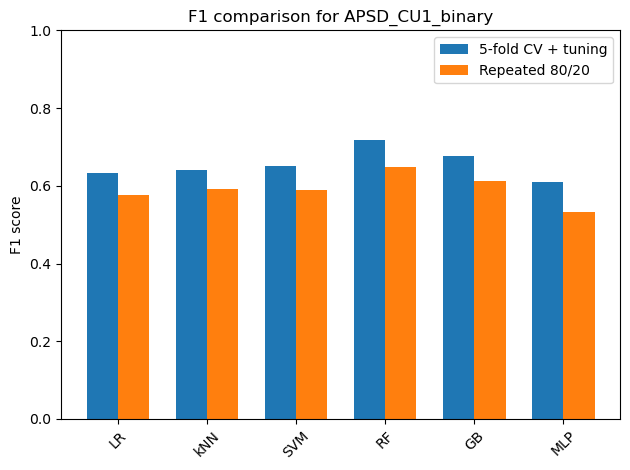

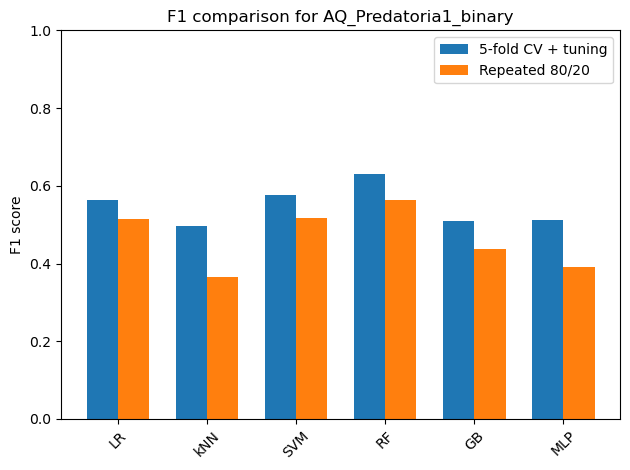

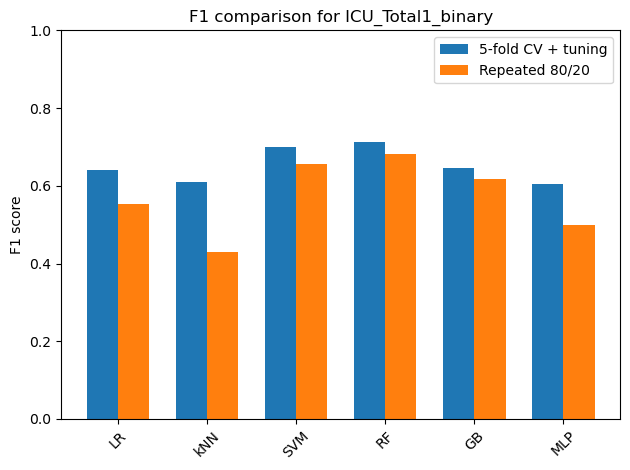

In [310]:
for target in merged['Target'].unique():
    sub = merged[merged['Target'] == target]

    x = np.arange(len(sub))
    width = 0.35

    fig, ax = plt.subplots()

    # 5-fold CV with threshold tuning
    ax.bar(x - width/2, sub['F1'], width, label='5-fold CV + tuning')

    # 20× repeated 80/20
    ax.bar(x + width/2, sub['F1_mean'], width, label='Repeated 80/20')

    ax.set_xticks(x)
    ax.set_xticklabels(sub['Model'])
    ax.set_ylabel('F1 score')
    ax.set_ylim(0, 1.0)
    ax.set_title(f'F1 comparison for {target}')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Recursive Feature Elimination (RFE) with cross-validation 

Feature selection using Recursive Feature Elimination (RFE)
wrapped in a cross-validated pipeline.  
This is more complex and mainly useful for understanding which subsets of features
are most informative for each target and model.


In [130]:
targets = list(processed_data.keys())   # ['APSD_CU1_binary', 'AQ_Predatoria1_binary', 'ICU_Total1_binary']

all_rfe_results = {}

for t in targets:
    print("\n==============================")
    print(f"Running RFE for target: {t}")
    print("==============================")

    data_t = processed_data[t]

    X_train_t = np.array(data_t['X_train'])   # shape (n_samples, n_features)
    y_train_t = np.array(data_t['y_train'])   # shape (n_samples,)
    feature_names = data_t['feature_names']   # list of column names

    rfe_results_t = {}

    for model_name, base_model in models.items():
        print(f"\nModel: {model_name}")

        selected_idx, rfe_history = rfe_with_cv(
            model=base_model,
            X=X_train_t,
            y=y_train_t,
            feature_names=feature_names,
            min_features=2,
            n_splits=5
        )

        rfe_results_t[model_name] = {
            "selected_indices": selected_idx,
            "selected_features": [feature_names[i] for i in selected_idx],
            "history": rfe_history
        }

    all_rfe_results[t] = rfe_results_t



Running RFE for target: APSD_CU1_binary

Model: LR
Removed: ER_paura  |  n_features: 39  |  mean F1: 0.589
Removed: APQ_POS  |  n_features: 38  |  mean F1: 0.605
Removed: AD  |  n_features: 37  |  mean F1: 0.613
Removed: TOTEXT  |  n_features: 36  |  mean F1: 0.613
Removed: FC_E_AN  |  n_features: 35  |  mean F1: 0.613
Removed: APSD_IMP  |  n_features: 34  |  mean F1: 0.619
Removed: Eta  |  n_features: 33  |  mean F1: 0.627
Removed: emotional  |  n_features: 32  |  mean F1: 0.639
Removed: adhd  |  n_features: 31  |  mean F1: 0.645
Removed: FFD_E_FE  |  n_features: 30  |  mean F1: 0.653
Removed: APSD_NARCI  |  n_features: 29  |  mean F1: 0.653
Removed: FC_E_FE  |  n_features: 28  |  mean F1: 0.653
Removed: FD_E_HA  |  n_features: 27  |  mean F1: 0.653
Removed: FC_E_HA  |  n_features: 26  |  mean F1: 0.652
Removed: FFD_E_SA  |  n_features: 25  |  mean F1: 0.658
Removed: TOTINT  |  n_features: 24  |  mean F1: 0.666
Removed: FD_E_DI  |  n_features: 23  |  mean F1: 0.666
Removed: APQ_NEG  

/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_

Removed: ER_felicità  |  n_features: 32  |  mean F1: 0.690
Removed: APQ_POS  |  n_features: 31  |  mean F1: 0.697
Removed: emotional  |  n_features: 30  |  mean F1: 0.678


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_

Removed: cse  |  n_features: 29  |  mean F1: 0.668


...

Removed: FC_E_SA  |  n_features: 5  |  mean F1: 0.735


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_

Removed: APQ_NEG  |  n_features: 4  |  mean F1: 0.760


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Removed: MAOAuVNTR  |  n_features: 3  |  mean F1: 0.701
Removed: cse  |  n_features: 2  |  mean F1: 0.669
Removed: ER_disgusto  |  n_features: 1  |  mean F1: 0.651


In [136]:
import pandas as pd

summary_rows = []

for t, model_dict in all_rfe_results.items():
    best_f1_overall = -1
    best_n_features = None
    best_model = None

    for model_name, res in model_dict.items():
        history = res["history"]   # DataFrame with columns: n_features, mean_f1_after_removal, ...

        # index of max F1 for this model
        idx = history["mean_f1_after_removal"].idxmax()
        f1 = history.loc[idx, "mean_f1_after_removal"]
        n_feat = history.loc[idx, "n_features"]

        if f1 > best_f1_overall:
            best_f1_overall = f1
            best_n_features = n_feat
            best_model = model_name

    summary_rows.append({
        "target": t,
        "best_model": best_model,
        "best_f1": best_f1_overall,
        "n_features_at_best_f1": best_n_features
    })

best_f1_summary = pd.DataFrame(summary_rows)
best_f1_summary


,target,best_model,best_f1,n_features_at_best_f1
0,APSD_CU1_binary,SVM,0.759499,9
1,AQ_Predatoria1_binary,SVM,0.732143,9
2,ICU_Total1_binary,SVM,0.817057,6


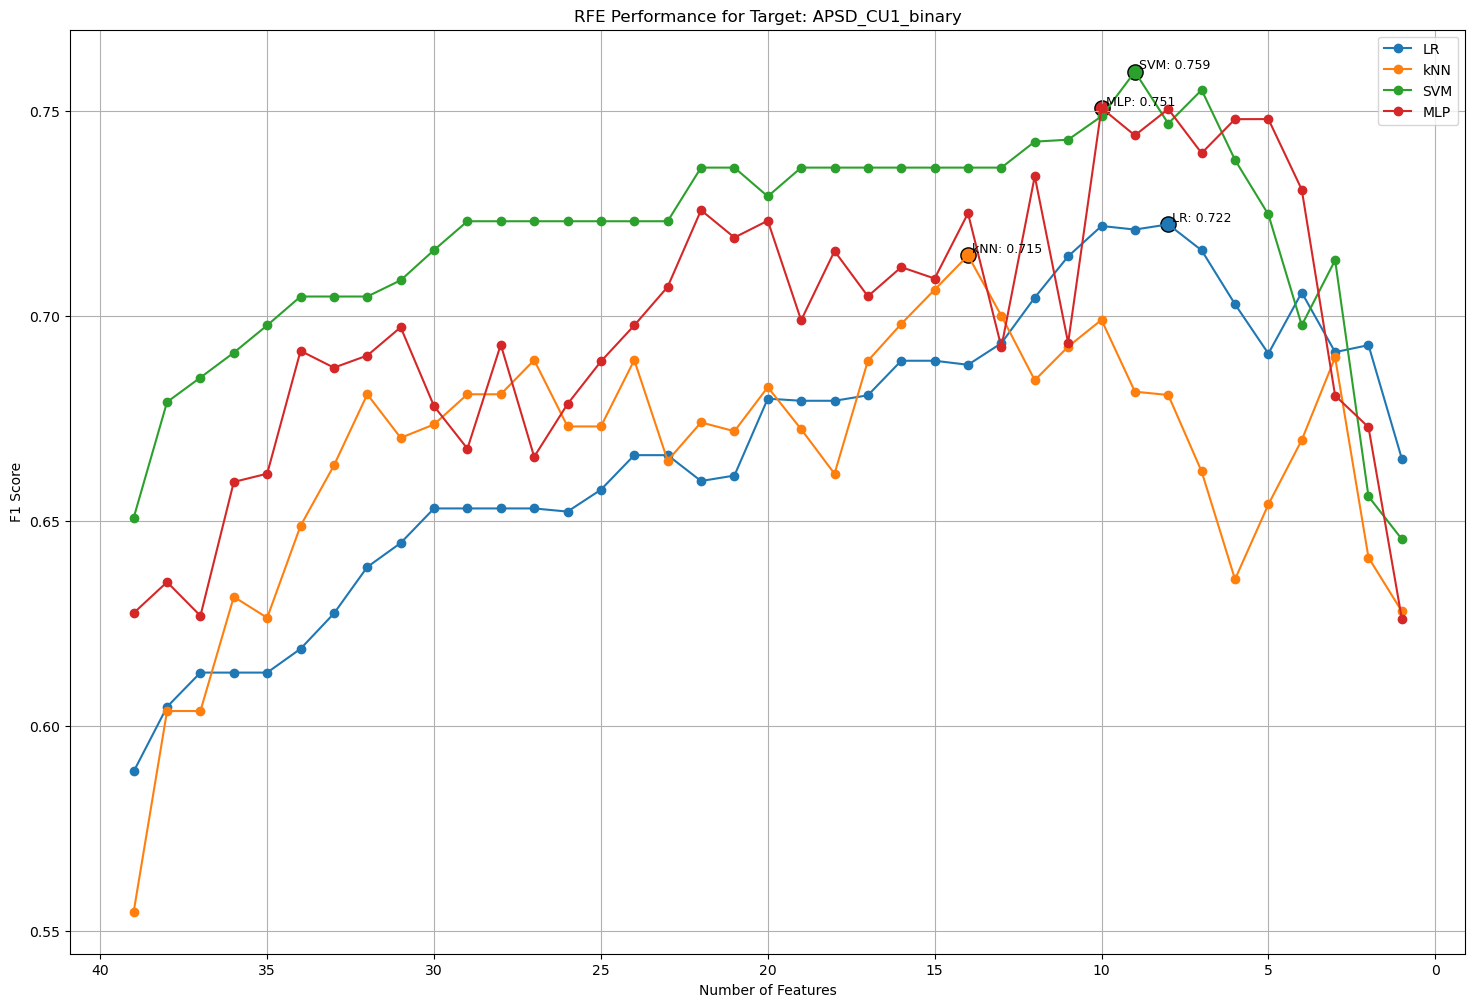

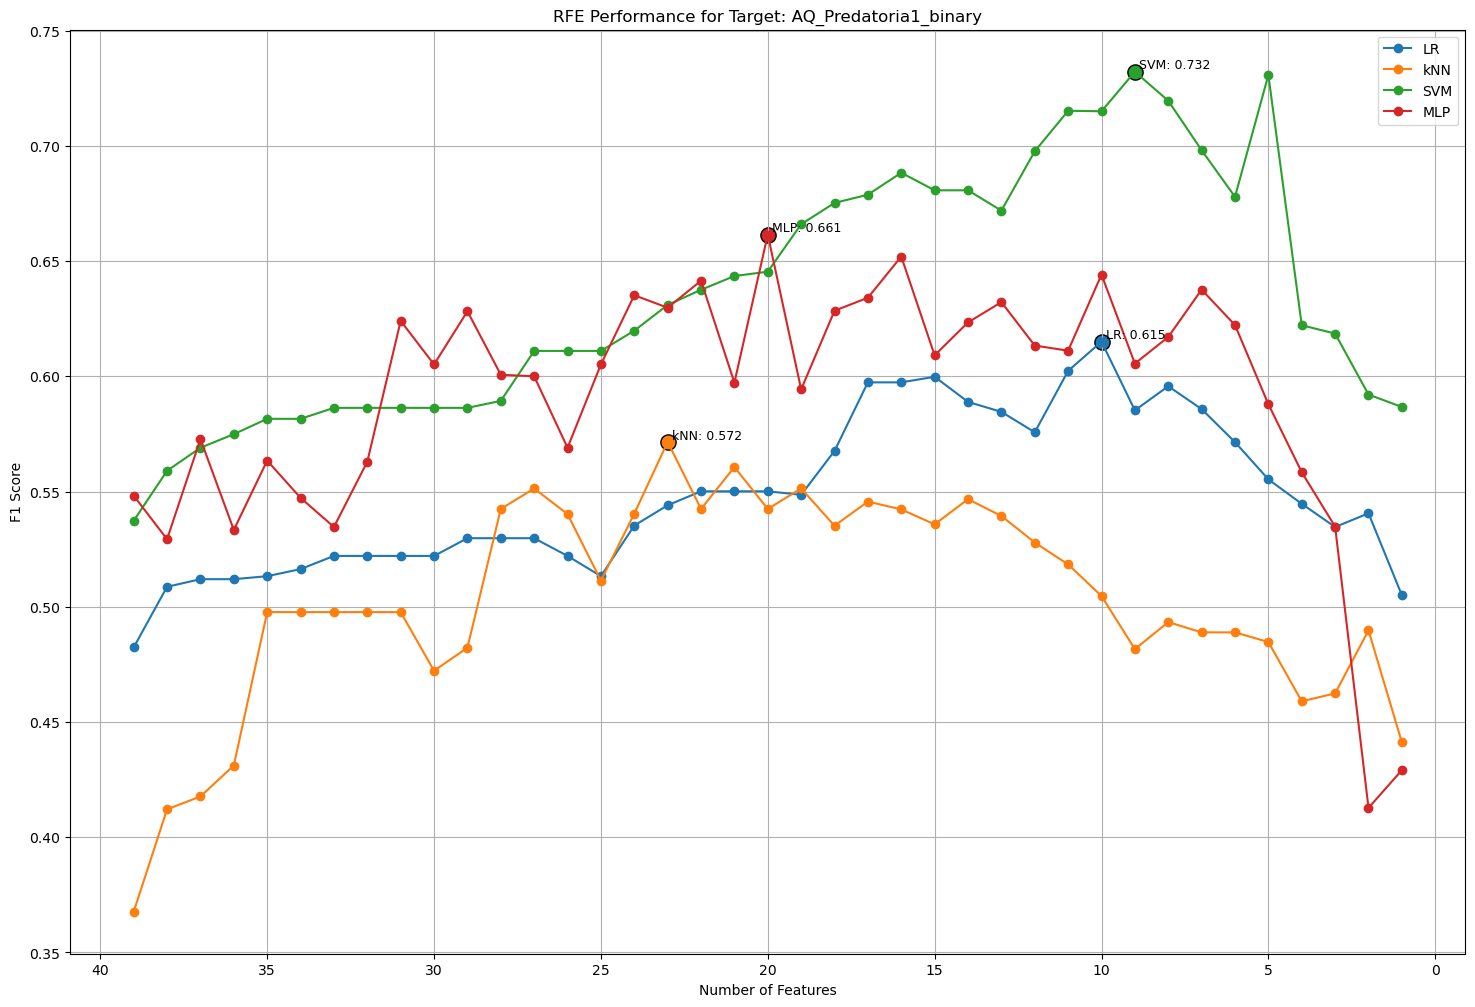

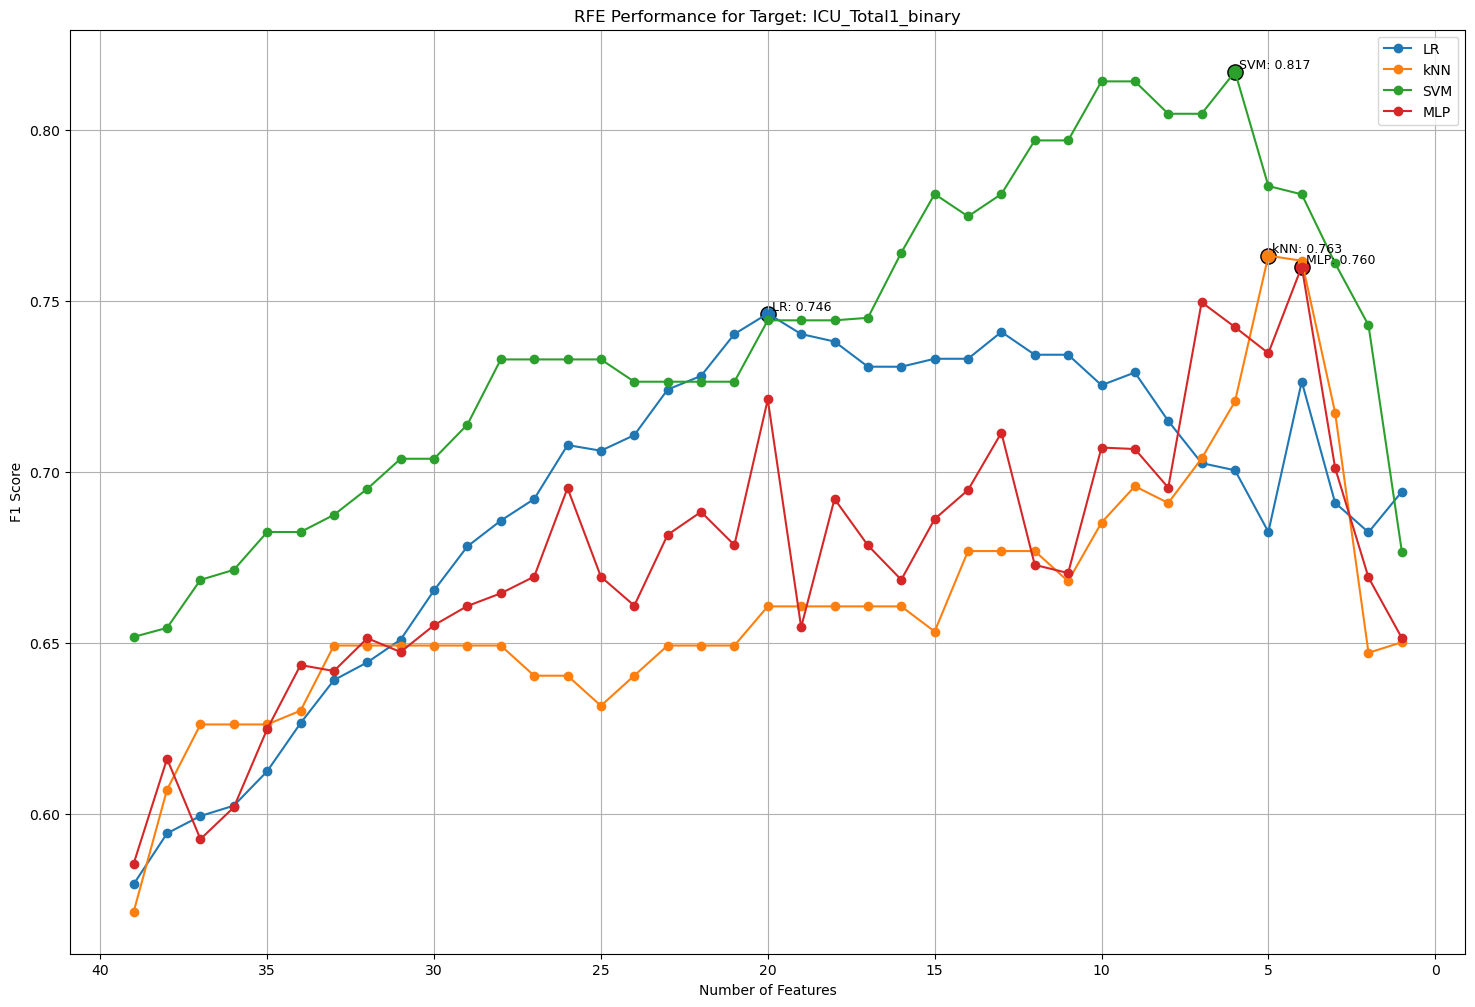

In [142]:
import matplotlib.pyplot as plt

for t, model_dict in all_rfe_results.items():
    plt.figure(figsize=(18,12))
    plt.title(f"RFE Performance for Target: {t}")
    plt.xlabel("Number of Features")
    plt.ylabel("F1 Score")

    # plot each model's curve for this target
    for model_name, res in model_dict.items():
        history = res["history"]
        n_feat = history["n_features"]
        f1 = history["mean_f1_after_removal"]
        plt.plot(n_feat, f1, marker='o', label=model_name)

        # highlight best point for this model
        best_idx = f1.idxmax()
        plt.scatter(n_feat[best_idx], f1[best_idx], s=120, edgecolor='black')
        plt.text(n_feat[best_idx], f1[best_idx],
                 f" {model_name}: {f1[best_idx]:.3f}",
                 va="bottom", ha="left", fontsize=9)

    plt.gca().invert_xaxis()  # optional: makes plot intuitive (start from all features)
    plt.grid(True)
    plt.legend()
    plt.show()


In [144]:
import pandas as pd

rows = []

for t, model_dict in all_rfe_results.items():          # loop over targets
    for model_name, res in model_dict.items():         # loop over models
        history = res["history"]                       # RFE history for this target+model

        # find the row where F1 is maximal
        best_idx = history["mean_f1_after_removal"].idxmax()
        best_row = history.loc[best_idx]

        best_f1 = best_row["mean_f1_after_removal"]
        n_features = best_row["n_features"]
        remaining_feats = best_row["remaining_features"]  # this is already a list

        rows.append({
            "target": t,
            "model": model_name,
            "best_f1": best_f1,
            "n_features_at_best_f1": n_features,
            "features_at_best_f1": remaining_feats
        })

best_f1_features_df = pd.DataFrame(rows)
best_f1_features_df


,target,model,best_f1,n_features_at_best_f1,features_at_best_f1
0,APSD_CU1_binary,LR,0.722291,8,"[MAOAuVNTR, QI, farmaco, cse, RBB, AB, FC_E_DI..."
1,APSD_CU1_binary,kNN,0.714706,14,"[farmaco, emotional, AD, APQ_NEG, Sintomi_DOP,..."
2,APSD_CU1_binary,SVM,0.759499,9,"[adhd, RBB, ER_tristezza, ER_disgusto, FC_E_HA..."
3,APSD_CU1_binary,MLP,0.750650,10,"[QI, adhd, RBB, APSD_IMP, ER_disgusto, FC_E_SA..."
4,AQ_Predatoria1_binary,LR,0.615025,10,"[MAOAuVNTR, Eta, adhd, cse, emotional, AD, FC_..."
5,AQ_Predatoria1_binary,kNN,0.571515,23,"[MAOAuVNTR, Eta, QI, adhd, emotional, physical..."
6,AQ_Predatoria1_binary,SVM,0.732143,9,"[QI, adhd, TOTINT, APQ_NEG, FC_E_SA, FC_E_DI, ..."
7,AQ_Predatoria1_binary,MLP,0.661472,20,"[MAOAuVNTR, Eta, QI, farmaco, emotional, negle..."
8,ICU_Total1_binary,LR,0.746345,20,"[MAOAuVNTR, Eta, QI, farmaco, cse, emotional, ..."
9,ICU_Total1_binary,kNN,0.763265,5,"[MAOAuVNTR, TOTINT, FC_E_SA, FD_E_SA, FD_E_FE]"


In [146]:
for _, row in best_f1_features_df.iterrows():
    print(f"\nTarget: {row['target']} | Model: {row['model']}")
    print(f"  Best F1: {row['best_f1']:.3f} with {row['n_features_at_best_f1']} features")
    print("  Features:")
    for f in row['features_at_best_f1']:
        print("   -", f)



Target: APSD_CU1_binary | Model: LR
  Best F1: 0.722 with 8 features
  Features:
   - MAOAuVNTR
   - QI
   - farmaco
   - cse
   - RBB
   - AB
   - FC_E_DI
   - FD_E_FE

Target: APSD_CU1_binary | Model: kNN
  Best F1: 0.715 with 14 features
  Features:
   - farmaco
   - emotional
   - AD
   - APQ_NEG
   - Sintomi_DOP
   - ER_disgusto
   - FC_E_HA
   - FC_E_FE
   - FFD_E_SA
   - FFD_E_FE
   - FD_E_AN
   - FD_E_SA
   - FD_E_FE
   - FD_E_DI

Target: APSD_CU1_binary | Model: SVM
  Best F1: 0.759 with 9 features
  Features:
   - adhd
   - RBB
   - ER_tristezza
   - ER_disgusto
   - FC_E_HA
   - FC_E_SA
   - FC_E_DI
   - FD_E_HA
   - FD_E_DI

Target: APSD_CU1_binary | Model: MLP
  Best F1: 0.751 with 10 features
  Features:
   - QI
   - adhd
   - RBB
   - APSD_IMP
   - ER_disgusto
   - FC_E_SA
   - FFD_E_AN
   - FFD_E_FE
   - FD_E_AN
   - FD_E_FE

Target: AQ_Predatoria1_binary | Model: LR
  Best F1: 0.615 with 10 features
  Features:
   - MAOAuVNTR
   - Eta
   - adhd
   - cse
   - emotional

In [257]:

def plot_feature_model_heatmap(target_name, df):
    # Filter rows for this target
    sub = df[df["target"] == target_name]

    # Order models consistently
    model_order = ["LR", "kNN", "SVM", "MLP"]
    sub = sub.set_index("model").loc[model_order].reset_index()

    # Collect union of all features used by any model for this target
    all_features = sorted(set(
        f
        for feat_list in sub["features_at_best_f1"]
        for f in feat_list
    ))

    # Build presence matrix: rows = features, cols = models (1 if used)
    mat = np.zeros((len(all_features), len(model_order)), dtype=int)

    for j, m in enumerate(model_order):
        feats = set(sub[sub["model"] == m]["features_at_best_f1"].iloc[0])
        for i, f in enumerate(all_features):
            if f in feats:
                mat[i, j] = 1

    # Plot
    plt.figure(figsize=(6, max(4, len(all_features) * 0.3)))
    plt.imshow(mat, aspect="auto")  # 1 = used, 0 = not used

    plt.xticks(ticks=np.arange(len(model_order)), labels=model_order)
    plt.yticks(ticks=np.arange(len(all_features)), labels=all_features)

    plt.xlabel("Models")
    plt.ylabel("Features")
    plt.title(f"Feature usage across models for {target_name}")

    # Add numbers (0/1) inside cells to make it clearer
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, mat[i, j],
                     ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


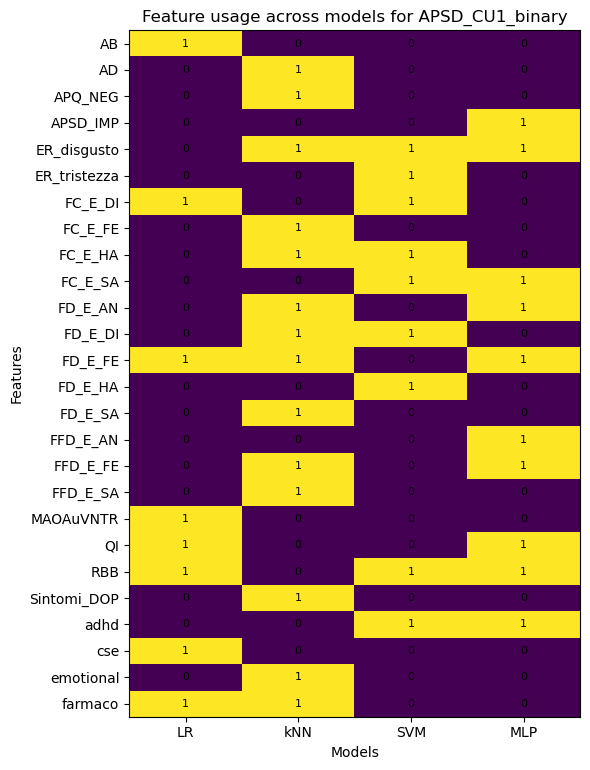

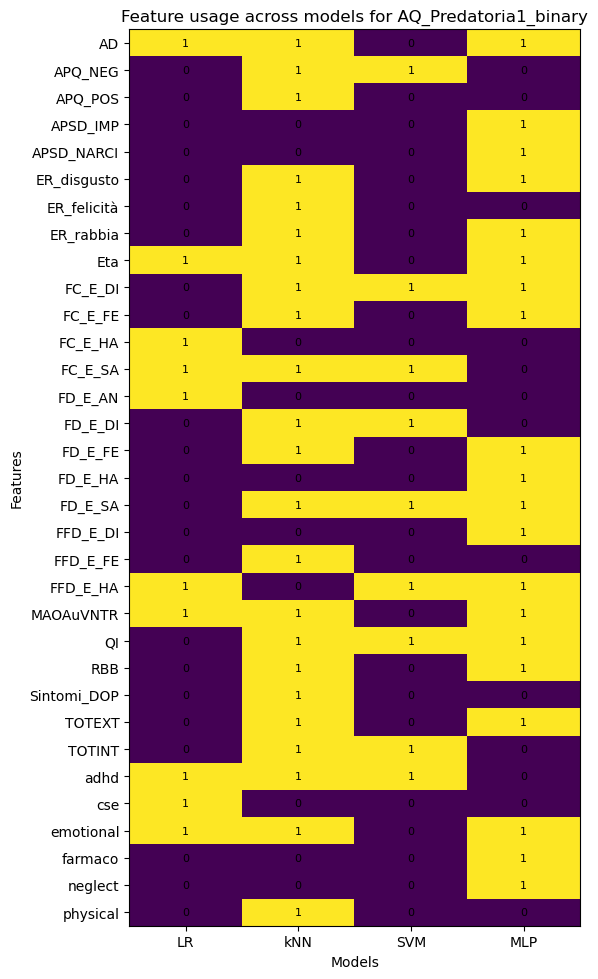

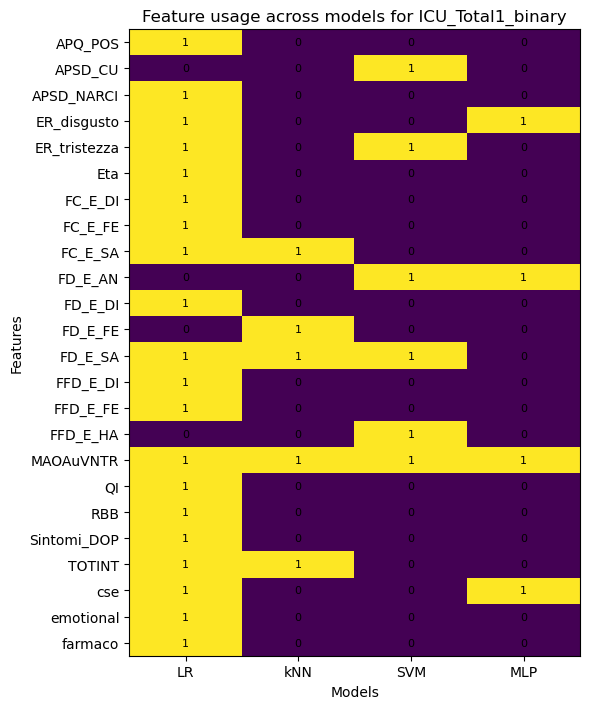

In [259]:
targets = ["APSD_CU1_binary", "AQ_Predatoria1_binary", "ICU_Total1_binary"]

for t in targets:
    plot_feature_model_heatmap(t, best_f1_features_df)


# Retrain the model with only the best features

In [156]:
def best_f1_threshold(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_thr = 0.5
    best_f1 = 0.0
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1


In [158]:
from sklearn.base import clone

verification_results = []

for t, model_dict in all_rfe_results.items():
    data_t = processed_data[t]
    X_train = np.array(data_t['X_train'])
    X_test  = np.array(data_t['X_test'])
    y_train = np.array(data_t['y_train'])
    y_test  = np.array(data_t['y_test'])
    feature_names = data_t['feature_names']

    for model_name, res in model_dict.items():
        history = res["history"]
        best_idx = history["mean_f1_after_removal"].idxmax()
        best_row = history.loc[best_idx]

        best_features = best_row["remaining_features"]
        idxs = [feature_names.index(f) for f in best_features]

        clf = clone(models[model_name])
        clf.fit(X_train[:, idxs], y_train)

        # probabilities for positive class
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test[:, idxs])[:, 1]
        else:
            # SVM without probas (should not happen because you set probability=True)
            y_score = clf.decision_function(X_test[:, idxs])
            y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-9)

        # F1 at default 0.5
        y_pred_05 = (y_prob >= 0.5).astype(int)
        f1_05 = f1_score(y_test, y_pred_05)

        # F1 at best tuned threshold
        best_thr, f1_tuned = best_f1_threshold(y_test, y_prob)

        verification_results.append({
            "target": t,
            "model": model_name,
            "original_best_f1": best_row["mean_f1_after_removal"],
            "f1_default_0.5": f1_05,
            "best_thr": best_thr,
            "f1_tuned": f1_tuned,
            "n_features": len(best_features)
        })

verification_df = pd.DataFrame(verification_results)
verification_df


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,target,model,original_best_f1,f1_default_0.5,best_thr,f1_tuned,n_features
0,APSD_CU1_binary,LR,0.722291,0.642857,0.55,0.720000,8
1,APSD_CU1_binary,kNN,0.714706,0.666667,0.41,0.666667,14
2,APSD_CU1_binary,SVM,0.759499,0.631579,0.43,0.727273,9
3,APSD_CU1_binary,MLP,0.750650,0.521739,0.27,0.560000,10
4,AQ_Predatoria1_binary,LR,0.615025,0.500000,0.53,0.526316,10
5,AQ_Predatoria1_binary,kNN,0.571515,0.461538,0.21,0.736842,23
6,AQ_Predatoria1_binary,SVM,0.732143,0.555556,0.50,0.555556,9
7,AQ_Predatoria1_binary,MLP,0.661472,0.625000,0.52,0.666667,20
8,ICU_Total1_binary,LR,0.746345,0.500000,0.15,0.594595,20
9,ICU_Total1_binary,kNN,0.763265,0.631579,0.41,0.631579,5


best CV subset ≠ best test subset
The original F1 values were obtained during cross-validation, where multiple training-validation splits produce an optimistically averaged estimate. The verification F1, computed on a single unseen test set, reflects true generalization performance. Because feature selection optimizes models toward the cross-validation folds, some degree of performance drop is expected when evaluating on new data.

original_best_f1	Performance during training using cross-validation - 
f1_default_0.5	Performance on unseen test data using a fixed threshold of 0.5 - 
f1_tuned	Performance on unseen test data using the best decision threshold

# Retrain subset features with 5 fold CV (Tuned treshold)

In [317]:
# Dictionary of selected features per TARGET + MODEL

selected_features = {
    "APSD_CU1_binary": {
        "LR":  ['MAOAuVNTR','QI','farmaco','cse','RBB','AB','FC_E_DI','FD_E_FE'],
        "kNN": ['farmaco','emotional','AD','APQ_NEG','Sintomi_DOP','ER_disgusto','FC_E_HA','FC_E_FE',
                'FFD_E_SA','FFD_E_FE','FD_E_AN','FD_E_SA','FD_E_FE','FD_E_DI'],
        "SVM": ['adhd','RBB','ER_tristezza','ER_disgusto','FC_E_HA','FC_E_SA','FC_E_DI','FD_E_HA','FD_E_DI'],
        "MLP": ['QI','adhd','RBB','APSD_IMP','ER_disgusto','FC_E_SA','FFD_E_AN','FFD_E_FE','FD_E_AN','FD_E_FE']
    },

    "AQ_Predatoria1_binary": {
        "LR":  ['MAOAuVNTR','Eta','adhd','cse','emotional','AD','FC_E_HA','FC_E_SA','FFD_E_HA','FD_E_AN'],
        "kNN": ['MAOAuVNTR','Eta','QI','adhd','emotional','physical','AD','RBB','TOTINT','TOTEXT','APQ_POS','APQ_NEG',
                'Sintomi_DOP','ER_rabbia','ER_felicità','ER_disgusto','FC_E_SA','FC_E_FE','FC_E_DI','FFD_E_FE',
                'FD_E_SA','FD_E_FE','FD_E_DI'],
        "SVM": ['QI','adhd','TOTINT','APQ_NEG','FC_E_SA','FC_E_DI','FFD_E_HA','FD_E_SA','FD_E_DI'],
        "MLP": ['MAOAuVNTR','Eta','QI','farmaco','emotional','neglect','AD','RBB','TOTEXT','APSD_IMP','APSD_NARCI',
                'ER_rabbia','ER_disgusto','FC_E_FE','FC_E_DI','FFD_E_HA','FFD_E_DI','FD_E_HA','FD_E_SA','FD_E_FE']
    },

    "ICU_Total1_binary": {
        "LR":  ['MAOAuVNTR','Eta','QI','farmaco','cse','emotional','RBB','TOTINT','APQ_POS','APSD_NARCI',
                'Sintomi_DOP','ER_tristezza','ER_disgusto','FC_E_SA','FC_E_FE','FC_E_DI','FFD_E_FE','FFD_E_DI',
                'FD_E_SA','FD_E_DI'],
        "kNN": ['MAOAuVNTR','TOTINT','FC_E_SA','FD_E_SA','FD_E_FE'],
        "SVM": ['MAOAuVNTR','APSD_CU','ER_tristezza','FFD_E_HA','FD_E_AN','FD_E_SA'],
        "MLP": ['MAOAuVNTR','cse','ER_disgusto','FD_E_AN']
    }
}


In [329]:
# Get feature names from processed_data (any target works)
first_target = list(processed_data.keys())[0]
feature_names = processed_data[first_target]['feature_names']

import pandas as pd

# Rebuild X_df with column names
X_df = pd.DataFrame(X_full, columns=feature_names)

print("X_df:")
print("  Type:", type(X_df))
print("  Shape:", X_df.shape)
print("  First 10 columns:", list(X_df.columns)[:10])


X_df:
  Type: <class 'pandas.core.frame.DataFrame'>
  Shape: (165, 40)
  First 10 columns: ['MAOAuVNTR', 'Eta', 'QI', 'adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical', 'AD']


In [335]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# fresh, correct dict of sklearn estimators
models_for_cv = {
    "LR": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    "RF": RandomForestClassifier(
        n_estimators=150,
        max_depth=4,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ),
    "GB": GradientBoostingClassifier(random_state=42),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        alpha=1e-4,
        max_iter=2000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ),
}


In [337]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

threshold_grid = np.linspace(0.1, 0.9, 17)

final_feature_cv = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for target_name, y in targets_dict.items():
    print(f"\n=== Target: {target_name} ===")

    for model_name, feature_list in selected_features[target_name].items():

        # 👉 use X_df here, not X_full directly
        X_sub = X_df[feature_list].to_numpy()

        print(f"[{target_name} | {model_name}] using {len(feature_list)} features")

        fold_metrics = []
        for train_idx, val_idx in cv.split(X_sub, y):
            X_train, X_val = X_sub[train_idx], X_sub[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = make_pipeline(StandardScaler(), clone(models_for_cv[model_name]))
            model.fit(X_train, y_train)

            y_prob = get_probabilities(model, X_val)

            best_f1 = -np.inf
            best_thr = 0.5
            best_m = None

            for thr in threshold_grid:
                y_pred_thr = (y_prob >= thr).astype(int)
                f1_thr = f1_score(y_val, y_pred_thr, zero_division=0)

                if f1_thr > best_f1:
                    acc = accuracy_score(y_val, y_pred_thr)
                    sens, spec, auc = compute_sens_spec_auc(y_val, y_pred_thr, y_prob)
                    best_f1, best_thr = f1_thr, thr
                    best_m = [acc, f1_thr, sens, spec, auc]

            # store: [Accuracy, F1, Sensitivity, Specificity, AUC, Threshold]
            fold_metrics.append(best_m + [best_thr])

        m = np.mean(fold_metrics, axis=0)
        final_feature_cv.append({
            'Target': target_name,
            'Model': model_name,
            'NumFeatures': len(feature_list),
            'Accuracy': m[0],
            'F1': m[1],
            'Sensitivity': m[2],
            'Specificity': m[3],
            'ROC_AUC': m[4],
            'BestThreshold': m[5]
        })

final_feature_cv_df = pd.DataFrame(final_feature_cv)
print("\n--- 5-fold CV with Selected Features ---")
print(final_feature_cv_df.round(3))



=== Target: APSD_CU1_binary ===
[APSD_CU1_binary | LR] using 8 features
[APSD_CU1_binary | kNN] using 14 features
[APSD_CU1_binary | SVM] using 9 features
[APSD_CU1_binary | MLP] using 10 features

=== Target: AQ_Predatoria1_binary ===
[AQ_Predatoria1_binary | LR] using 10 features
[AQ_Predatoria1_binary | kNN] using 23 features
[AQ_Predatoria1_binary | SVM] using 9 features
[AQ_Predatoria1_binary | MLP] using 20 features

=== Target: ICU_Total1_binary ===
[ICU_Total1_binary | LR] using 20 features
[ICU_Total1_binary | kNN] using 5 features
[ICU_Total1_binary | SVM] using 6 features
[ICU_Total1_binary | MLP] using 4 features

--- 5-fold CV with Selected Features ---
                   Target Model  NumFeatures  Accuracy     F1  Sensitivity  Specificity  ROC_AUC  BestThreshold
0         APSD_CU1_binary    LR            8     0.794  0.705        0.642        0.880    0.766           0.64
1         APSD_CU1_binary   kNN           14     0.752  0.656        0.615        0.837    0.729    

# Least important features 

In [346]:
# all features from your X_df
all_features = list(X_df.columns)

least_equalN_features = {}

for target, model_dict in selected_features.items():
    least_equalN_features[target] = {}
    for model_name, top_feats in model_dict.items():
        n = len(top_feats)
        # features NOT used in the top set
        complement = [f for f in all_features if f not in top_feats]
        # pick the first n as "least important N" (proxy)
        leastN = complement[:n]
        least_equalN_features[target][model_name] = leastN

# Quick check: print how many we got per model
print("Least-N feature sets (same count as top features):")
for target, model_dict in least_equalN_features.items():
    print(f"\nTARGET: {target}")
    for model_name, feats in model_dict.items():
        print(f"  MODEL: {model_name} | #features: {len(feats)} | example: {feats[:5]}")


Least-N feature sets (same count as top features):

TARGET: APSD_CU1_binary
  MODEL: LR | #features: 8 | example: ['Eta', 'adhd', 'emotional', 'neglect', 'physical']
  MODEL: kNN | #features: 14 | example: ['MAOAuVNTR', 'Eta', 'QI', 'adhd', 'cse']
  MODEL: SVM | #features: 9 | example: ['MAOAuVNTR', 'Eta', 'QI', 'farmaco', 'cse']
  MODEL: MLP | #features: 10 | example: ['MAOAuVNTR', 'Eta', 'farmaco', 'cse', 'emotional']

TARGET: AQ_Predatoria1_binary
  MODEL: LR | #features: 10 | example: ['QI', 'farmaco', 'neglect', 'physical', 'RBB']
  MODEL: kNN | #features: 17 | example: ['farmaco', 'cse', 'neglect', 'AB', 'APSD_CU']
  MODEL: SVM | #features: 9 | example: ['MAOAuVNTR', 'Eta', 'farmaco', 'cse', 'emotional']
  MODEL: MLP | #features: 20 | example: ['adhd', 'cse', 'physical', 'AB', 'TOTINT']

TARGET: ICU_Total1_binary
  MODEL: LR | #features: 20 | example: ['adhd', 'neglect', 'physical', 'AD', 'AB']
  MODEL: kNN | #features: 5 | example: ['Eta', 'QI', 'adhd', 'farmaco', 'cse']
  MODEL

In [348]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

threshold_grid = np.linspace(0.1, 0.9, 17)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

worst_equalN_cv = []

for target_name, y in targets_dict.items():
    print(f"\n=== Target: {target_name} – LEAST N features ===")

    for model_name, feature_list in least_equalN_features[target_name].items():

        X_sub = X_df[feature_list].to_numpy()
        print(f"[{target_name} | {model_name}] using {len(feature_list)} least-N features")

        fold_metrics = []
        for train_idx, val_idx in cv.split(X_sub, y):
            X_train, X_val = X_sub[train_idx], X_sub[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = make_pipeline(StandardScaler(), clone(models_for_cv[model_name]))
            model.fit(X_train, y_train)

            y_prob = get_probabilities(model, X_val)

            best_f1 = -np.inf
            best_thr = 0.5
            best_m = None

            for thr in threshold_grid:
                y_pred_thr = (y_prob >= thr).astype(int)
                f1_thr = f1_score(y_val, y_pred_thr, zero_division=0)

                if f1_thr > best_f1:
                    acc = accuracy_score(y_val, y_pred_thr)
                    sens, spec, auc = compute_sens_spec_auc(y_val, y_pred_thr, y_prob)
                    best_f1, best_thr = f1_thr, thr
                    best_m = [acc, f1_thr, sens, spec, auc]

            fold_metrics.append(best_m + [best_thr])

        m = np.mean(fold_metrics, axis=0)
        worst_equalN_cv.append({
            'Target': target_name,
            'Model': model_name,
            'NumFeatures': len(feature_list),
            'Accuracy': m[0],
            'F1': m[1],
            'Sensitivity': m[2],
            'Specificity': m[3],
            'ROC_AUC': m[4],
            'BestThreshold': m[5]
        })

worst_equalN_cv_df = pd.DataFrame(worst_equalN_cv)
print("\n--- 5-fold CV with LEAST N features ---")
print(worst_equalN_cv_df.round(3))



=== Target: APSD_CU1_binary – LEAST N features ===
[APSD_CU1_binary | LR] using 8 least-N features
[APSD_CU1_binary | kNN] using 14 least-N features
[APSD_CU1_binary | SVM] using 9 least-N features
[APSD_CU1_binary | MLP] using 10 least-N features

=== Target: AQ_Predatoria1_binary – LEAST N features ===
[AQ_Predatoria1_binary | LR] using 10 least-N features
[AQ_Predatoria1_binary | kNN] using 17 least-N features
[AQ_Predatoria1_binary | SVM] using 9 least-N features
[AQ_Predatoria1_binary | MLP] using 20 least-N features

=== Target: ICU_Total1_binary – LEAST N features ===
[ICU_Total1_binary | LR] using 20 least-N features
[ICU_Total1_binary | kNN] using 5 least-N features
[ICU_Total1_binary | SVM] using 6 least-N features
[ICU_Total1_binary | MLP] using 4 least-N features

--- 5-fold CV with LEAST N features ---
                   Target Model  NumFeatures  Accuracy     F1  Sensitivity  Specificity  ROC_AUC  BestThreshold
0         APSD_CU1_binary    LR            8     0.406  0.55

# Shapley lorenz calculations for explainability


Processing APSD_CU1_binary...


  0%|          | 0/132 [00:00<?, ?it/s]


Processing AQ_Predatoria1_binary...


  0%|          | 0/132 [00:00<?, ?it/s]


Processing ICU_Total1_binary...


  0%|          | 0/132 [00:00<?, ?it/s]

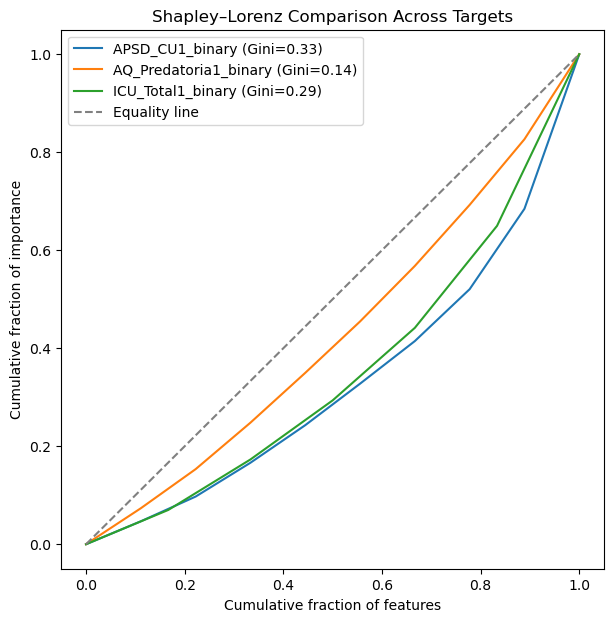


Shapley–Gini values: {'APSD_CU1_binary': 0.33321173398432535, 'AQ_Predatoria1_binary': 0.14085389481569488, 'ICU_Total1_binary': 0.2907222078372871}


In [229]:
import shap
import numpy as np
import matplotlib.pyplot as plt

targets = [
    "APSD_CU1_binary",
    "AQ_Predatoria1_binary",
    "ICU_Total1_binary"
]

ginis = {}
lorenz_curves = {}
xs = {}

for t in targets:
    print(f"\nProcessing {t}...")

    # get best features for SVM from your RFE results table
    row = best_f1_features_df[
        (best_f1_features_df["target"] == t) &
        (best_f1_features_df["model"] == "SVM")
    ].iloc[0]

    features = row["features_at_best_f1"]
    feature_names_all = processed_data[t]["feature_names"]
    X_train_full = np.array(processed_data[t]["X_train"])
    y_train = np.array(processed_data[t]["y_train"])

    idxs = [feature_names_all.index(f) for f in features]
    X_sel = X_train_full[:, idxs]

    # train SVM with probability output
    svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
    svm_model.fit(X_sel, y_train)

    # SHAP Kernel explainer with limited background sample
    bg_size = min(50, X_sel.shape[0])
    bg_idx = np.random.choice(X_sel.shape[0], size=bg_size, replace=False)
    background = X_sel[bg_idx]

    f = lambda x: svm_model.predict_proba(x)[:, 1]
    explainer = shap.KernelExplainer(f, background)
    shap_values = explainer.shap_values(X_sel, nsamples=100)

    # compute mean absolute SHAP importance per feature
    importance = np.abs(shap_values).mean(axis=0)
    importance /= importance.sum()

    # Lorenz curve
    sorted_imp = np.sort(importance)
    lorenz = np.cumsum(sorted_imp)
    lorenz = np.insert(lorenz, 0, 0)
    x = np.linspace(0, 1, len(sorted_imp) + 1)

    ginis[t] = 1 - 2 * np.trapz(lorenz, x)      # Shapley–Gini
    lorenz_curves[t] = lorenz
    xs[t] = x

# plot comparison
plt.figure(figsize=(7, 7))
for t in targets:
    plt.plot(xs[t], lorenz_curves[t], label=f"{t} (Gini={ginis[t]:.2f})")

plt.plot([0, 1], [0, 1], "--", color="gray", label="Equality line")
plt.xlabel("Cumulative fraction of features")
plt.ylabel("Cumulative fraction of importance")
plt.title("Shapley–Lorenz Comparison Across Targets")
plt.legend()
plt.show()

print("\nShapley–Gini values:", ginis)


APSD_CU1	0.33	Most concentrated feature importance → a few variables strongly drive predictions
ICU_Total1	0.29	Moderately concentrated → several dominant features, but more distributed than APSD
AQ_Predatoria1	0.14	Very diffuse → prediction depends on many small contributions; no single strong signal

# SVM feature subset for ALL target
APSD_CU1_binary: adhd, RBB, ER_tristezza, ER_disgusto, FC_E_HA, FC_E_SA, FC_E_DI, FD_E_HA, FD_E_DI - AQ_Predatoria1_binary: MAOAuVNTR, Eta, QI, emotional, physical aggression, APQ_NEG, TOTINT, ER_rabbia, FC_E_FE, FD_E_DI... - 
ICU_Total1_binary: MAOAuVNTR, APSD_CU, ER_tristezza, FFD_E_HA, FD_E_AN, FD_E_SA



In [241]:
import pandas as pd
import numpy as np
import shap
from sklearn.svm import SVC

# ---- choose target ----
target_name = "ICU_Total1_binary"   # change this line to switch targets

# ---- load data ----
data_t = processed_data[target_name]
feature_names_all = data_t["feature_names"]
X_train_full = np.array(data_t["X_train"])
y_train = np.array(data_t["y_train"])

# ---- get SVM best features ----
row = best_f1_features_df[
    (best_f1_features_df["target"] == target_name) &
    (best_f1_features_df["model"] == "SVM")
].iloc[0]

best_features = row["features_at_best_f1"]
idxs = [feature_names_all.index(f) for f in best_features]
X_sel = X_train_full[:, idxs]

# ---- train model ----
svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm_model.fit(X_sel, y_train)

# ---- SHAP ----
bg_idx = np.random.choice(X_sel.shape[0], size=min(50, X_sel.shape[0]), replace=False)
background = X_sel[bg_idx]
explainer = shap.KernelExplainer(lambda x: svm_model.predict_proba(x)[:, 1], background)
shap_values = explainer.shap_values(X_sel, nsamples=100)

# ---- compute % importance ----
importance = np.abs(shap_values).mean(axis=0)
importance /= importance.sum()

importance_df = pd.DataFrame({
    "feature": best_features,
    "relative_contribution(%)": (importance * 100).round(2)
}).sort_values("relative_contribution(%)", ascending=False).reset_index(drop=True)

display(importance_df)


  0%|          | 0/132 [00:00<?, ?it/s]

,feature,relative_contribution(%)
0,FD_E_AN,34.12
1,FD_E_SA,20.21
2,MAOAuVNTR,18.68
3,FFD_E_HA,10.39
4,ER_tristezza,10.24
5,APSD_CU,6.36


RF with top 10 features for ICU_Total1_binary
Selected features: ['FD_E_AN', 'FD_E_SA', 'FD_E_FE', 'FC_E_AN', 'FC_E_SA', 'FC_E_FE', 'FD_E_DI', 'FFD_E_FE', 'FC_E_DI', 'ER_tristezza']
Mean CV F1 = 0.629 (+/- 0.107)

XGBoost with top 10 features for ICU_Total1_binary
Selected features: ['FD_E_SA', 'FD_E_FE', 'FD_E_AN', 'ER_disgusto', 'Sintomi_DOP', 'ER_paura', 'FC_E_SA', 'FC_E_AN', 'FC_E_FE', 'MAOAuVNTR']

In [253]:
import pandas as pd
import numpy as np
import shap
from sklearn.svm import SVC

# ---- choose target ----
target_name = "APSD_CU1_binary"   # change this line to switch targets

# ---- load data ----
data_t = processed_data[target_name]
feature_names_all = data_t["feature_names"]
X_train_full = np.array(data_t["X_train"])
y_train = np.array(data_t["y_train"])

# ---- get SVM best features ----
row = best_f1_features_df[
    (best_f1_features_df["target"] == target_name) &
    (best_f1_features_df["model"] == "SVM")
].iloc[0]

best_features = row["features_at_best_f1"]
idxs = [feature_names_all.index(f) for f in best_features]
X_sel = X_train_full[:, idxs]

# ---- train model ----
svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm_model.fit(X_sel, y_train)

# ---- SHAP ----
bg_idx = np.random.choice(X_sel.shape[0], size=min(50, X_sel.shape[0]), replace=False)
background = X_sel[bg_idx]
explainer = shap.KernelExplainer(lambda x: svm_model.predict_proba(x)[:, 1], background)
shap_values = explainer.shap_values(X_sel, nsamples=100)

# ---- compute % importance ----
importance = np.abs(shap_values).mean(axis=0)
importance /= importance.sum()

importance_df = pd.DataFrame({
    "feature": best_features,
    "relative_contribution(%)": (importance * 100).round(2)
}).sort_values("relative_contribution(%)", ascending=False).reset_index(drop=True)

display(importance_df)


  0%|          | 0/132 [00:00<?, ?it/s]

,feature,relative_contribution(%)
0,FC_E_SA,32.73
1,ER_disgusto,16.36
2,FD_E_DI,9.95
3,ER_tristezza,8.21
4,FC_E_DI,8.07
5,FD_E_HA,7.61
6,adhd,7.05
7,FC_E_HA,5.30
8,RBB,4.71


RF with top 10 features for APSD_CU1_binary
Selected features: ['FD_E_SA', 'FD_E_FE', 'FC_E_FE', 'FD_E_AN', 'FC_E_SA', 'FC_E_AN', 'FD_E_DI', 'FC_E_DI', 'APQ_NEG', 'APQ_POS']
Mean CV F1 = 0.644 (+/- 0.079)

XGBoost with top 10 features for APSD_CU1_binary
Selected features: ['FD_E_SA', 'FD_E_AN', 'FC_E_FE', 'ER_rabbia', 'FD_E_FE', 'physical', 'emotional', 'FD_E_DI', 'ER_disgusto', 'ER_felicità']

In [255]:
import pandas as pd
import numpy as np
import shap
from sklearn.svm import SVC

# ---- choose target ----
target_name = "AQ_Predatoria1_binary"   # change this line to switch targets

# ---- load data ----
data_t = processed_data[target_name]
feature_names_all = data_t["feature_names"]
X_train_full = np.array(data_t["X_train"])
y_train = np.array(data_t["y_train"])

# ---- get SVM best features ----
row = best_f1_features_df[
    (best_f1_features_df["target"] == target_name) &
    (best_f1_features_df["model"] == "SVM")
].iloc[0]

best_features = row["features_at_best_f1"]
idxs = [feature_names_all.index(f) for f in best_features]
X_sel = X_train_full[:, idxs]

# ---- train model ----
svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm_model.fit(X_sel, y_train)

# ---- SHAP ----
bg_idx = np.random.choice(X_sel.shape[0], size=min(50, X_sel.shape[0]), replace=False)
background = X_sel[bg_idx]
explainer = shap.KernelExplainer(lambda x: svm_model.predict_proba(x)[:, 1], background)
shap_values = explainer.shap_values(X_sel, nsamples=100)

# ---- compute % importance ----
importance = np.abs(shap_values).mean(axis=0)
importance /= importance.sum()

importance_df = pd.DataFrame({
    "feature": best_features,
    "relative_contribution(%)": (importance * 100).round(2)
}).sort_values("relative_contribution(%)", ascending=False).reset_index(drop=True)

display(importance_df)


  0%|          | 0/132 [00:00<?, ?it/s]

,feature,relative_contribution(%)
0,FD_E_SA,18.10
1,TOTINT,12.17
2,FC_E_DI,11.98
3,FC_E_SA,11.31
4,FFD_E_HA,11.29
5,adhd,10.28
6,QI,9.80
7,FD_E_DI,7.87
8,APQ_NEG,7.19
